# 4.SQL and Dataframes

References:

* Spark-SQL, <https://spark.apache.org/docs/latest/sql-programming-guide.html#datasets-and-dataframes>


# 4.1  Example Walkthrough
Follow the Spark SQL and DataFrames examples below.

### Initialize PySpark

In [2]:
!pip install -q pyspark

In [3]:
# Show available CPU cores (useful for configuring Spark parallelism)
import multiprocessing
print(f"Available CPU cores: {multiprocessing.cpu_count()}")

Available CPU cores: 2


In [4]:
# Initialize PySpark
import os, sys
APP_NAME = "PySpark Lecture"
SPARK_MASTER="local[2]"
import pyspark
import pyspark.sql
from pyspark.sql import Row
conf=pyspark.SparkConf()
conf=pyspark.SparkConf().setAppName(APP_NAME).set("spark.local.dir", os.path.join(os.getcwd(), "tmp"))
sc = pyspark.SparkContext(master=SPARK_MASTER, conf=conf)
spark = pyspark.sql.SparkSession(sc).builder.appName(APP_NAME).getOrCreate()

print("PySpark initiated...")

PySpark initiated...


### Hello, World!

Loading data, mapping it and collecting the records into RAM...

In [5]:
!wget https://raw.githubusercontent.com/scalable-infrastructure/exercise-2026/main/data/example.csv

--2026-04-03 08:16:28--  https://raw.githubusercontent.com/scalable-infrastructure/exercise-2026/main/data/example.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 189 [text/plain]
Saving to: ‘example.csv’

example.csv         100%[===================>]     189  --.-KB/s    in 0s      

2026-04-03 08:16:29 (4.51 MB/s) - ‘example.csv’ saved [189/189]



In [6]:
# Load the text file using the SparkContext
csv_lines = sc.textFile("example.csv")

# Map the data to split the lines into a list
data = csv_lines.map(lambda line: line.split(","))

# Collect the dataset into local RAM
data.collect()

[['Russell Jurney', 'Relato', 'CEO'],
 ['Florian Liebert', 'Mesosphere', 'CEO'],
 ['Don Brown', 'Rocana', 'CIO'],
 ['Steve Jobs', 'Apple', 'CEO'],
 ['Donald Trump', 'The Trump Organization', 'CEO'],
 ['Russell Jurney', 'Data Syndrome', 'Principal Consultant']]

### Creating Rows

Creating `pyspark.sql.Rows` out of your data so you can create DataFrames...

In [7]:
# Convert the CSV into a pyspark.sql.Row
def csv_to_row(line):
    parts = line.split(",")
    row = Row(
      name=parts[0],
      company=parts[1],
      title=parts[2]
    )
    return row

# Apply the function to get rows in an RDD
rows = csv_lines.map(csv_to_row)

### Creating DataFrames from RDDs

Using the `RDD.toDF()` method to create a dataframe, registering the `DataFrame` as a temporary table with Spark SQL, and counting the jobs per person using Spark SQL.

In [8]:
# Convert to a pyspark.sql.DataFrame
rows_df = rows.toDF()

# Register the DataFrame for Spark SQL
rows_df.registerTempTable("executives")

# Generate a new DataFrame with SQL using the SparkSession
job_counts = spark.sql("""
SELECT
  name,
  COUNT(*) AS total
  FROM executives
  GROUP BY name
""")
job_counts.show()

# Go back to an RDD
job_counts.rdd.collect()

/usr/local/lib/python3.12/dist-packages/pyspark/sql/classic/dataframe.py:178: FutureWarning: Deprecated in 2.0, use createOrReplaceTempView instead.
  warnings.warn("Deprecated in 2.0, use createOrReplaceTempView instead.", FutureWarning)


+---------------+-----+
|           name|total|
+---------------+-----+
|Florian Liebert|    1|
|      Don Brown|    1|
| Russell Jurney|    2|
|     Steve Jobs|    1|
|   Donald Trump|    1|
+---------------+-----+



[Row(name='Florian Liebert', total=1),
 Row(name='Don Brown', total=1),
 Row(name='Russell Jurney', total=2),
 Row(name='Steve Jobs', total=1),
 Row(name='Donald Trump', total=1)]

# 4.2–4.7 NASA Dataset

## 4.2
Create a Spark SQL table with fields for IP/Host and Response Code from the NASA log file.

In [11]:
# Download and unzip the NASA log file
!wget "https://github.com/scalable-infrastructure/exercise-2026/blob/main/data/nasa/NASA_access_log_Jul95.gz?raw=true" -O NASA_access_log_Jul95.gz
!gzip -d NASA_access_log_Jul95.gz

--2026-04-03 08:18:09--  https://github.com/scalable-infrastructure/exercise-2026/blob/main/data/nasa/NASA_access_log_Jul95.gz?raw=true
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/scalable-infrastructure/exercise-2026/raw/refs/heads/main/data/nasa/NASA_access_log_Jul95.gz [following]
--2026-04-03 08:18:10--  https://github.com/scalable-infrastructure/exercise-2026/raw/refs/heads/main/data/nasa/NASA_access_log_Jul95.gz
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/scalable-infrastructure/exercise-2026/refs/heads/main/data/nasa/NASA_access_log_Jul95.gz [following]
--2026-04-03 08:18:10--  https://raw.githubusercontent.com/scalable-infrastructure/exercise-2026/refs/heads/main/data/nasa/NASA_access_log_Jul95.gz
Resolving raw.githubusercontent

In [12]:
# Load the raw log file
nasa_rdd = sc.textFile("NASA_access_log_Jul95")

# Function to safely parse host and HTTP status code from the log lines
def parse_log(line):
    parts = line.split()
    if len(parts) >= 2:
        # Host is the 1st element, Status code is typically the 2nd to last
        return Row(host=parts[0], status=parts[-2])
    return Row(host="UNKNOWN", status="UNKNOWN")

# Map the RDD, filter out invalid rows, and convert to DataFrame
parsed_rdd = nasa_rdd.map(parse_log).filter(lambda r: r.status.isdigit())
nasa_df = parsed_rdd.toDF()

# Register the DataFrame as a temporary Spark SQL table
nasa_df.createOrReplaceTempView("nasa_logs")
print("Spark SQL table 'nasa_logs' created successfully.")

Spark SQL table 'nasa_logs' created successfully.


## 4.3
Run an SQL query that outputs the number of occurrences of each HTTP response code.

## 4.4
Implement the same query using the DataFrame API.

In [15]:
#A4.3
sql_counts = spark.sql("""
    SELECT status, COUNT(*) AS total
    FROM nasa_logs
    GROUP BY status
    ORDER BY total DESC
""")

print("(Spark SQL)")
sql_counts.show()

#A4.4
import pyspark.sql.functions as F

# Use DataFrame methods instead of raw SQL strings
df_counts = nasa_df.groupBy("status") \
                   .agg(F.count("*").alias("total")) \
                   .orderBy(F.col("total").desc())

print("(DataFrame API)")
df_counts.show()

(Spark SQL)
+------+-------+
|status|  total|
+------+-------+
|   200|1701534|
|   304| 132627|
|   302|  46573|
|   404|  10845|
|   500|     62|
|   403|     54|
|   501|     14|
|   400|      5|
+------+-------+

(DataFrame API)
+------+-------+
|status|  total|
+------+-------+
|   200|1701534|
|   304| 132627|
|   302|  46573|
|   404|  10845|
|   500|     62|
|   403|     54|
|   501|     14|
|   400|      5|
+------+-------+



## 4.5
Cache the DataFrame and run the same query again. Measure the runtime for caching and for executing the query.

In [16]:
import time

# Cache the DataFrame into memory
nasa_df.cache()

# Measure the time it takes to force the data into the cache
start_cache = time.time()
nasa_df.count()
end_cache = time.time()

# Measure the time it takes to execute our query now that data is cached
start_query = time.time()
nasa_df.groupBy("status").count().collect()
end_query = time.time()

print(f"Time required to cache the data: {end_cache - start_cache:.4f} seconds")
print(f"Time required to run query on cached data: {end_query - start_query:.4f} seconds")

Time required to cache the data: 11.7980 seconds
Time required to run query on cached data: 2.0116 seconds


## 4.6 Performance Analysis — Weak Scaling
* Create RDDs with 2x, 4x, 8x, and 16x the size of the NASA log dataset. Persist the dataset in the Spark cache. Use an appropriate number of cores (e.g. 8 or 16).
* Measure and plot the response times for all datasets using a constant number of cores.
* Plot the results.
* Explain the results.


Measuring response times for scaling datasets...
Dataset 1x: 0.4747 seconds
Dataset 2x: 0.6636 seconds
Dataset 4x: 1.3039 seconds
Dataset 8x: 2.2724 seconds
Dataset 16x: 3.5250 seconds


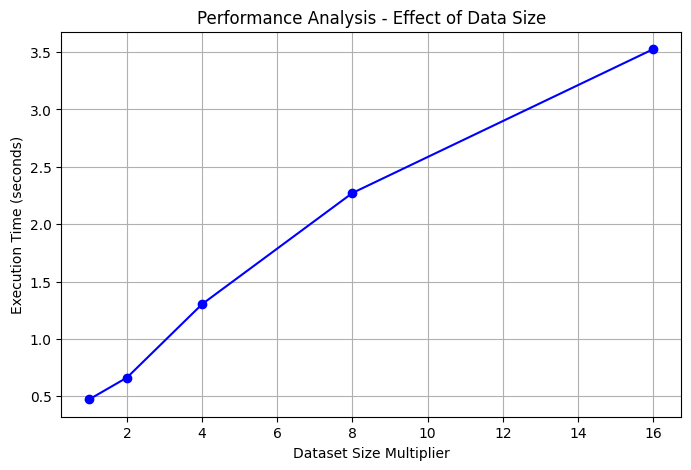


Explanation:
As the dataset size increases exponentially, the execution time increases almost linearly. Because the processing power (number of cores) remains constant, the system has to process strictly more data chunks in a sequential manner.


In [17]:
import matplotlib.pyplot as plt

# Create 2x, 4x, 8x, and 16x datasets
df_1x = nasa_df
df_2x = df_1x.union(df_1x)
df_4x = df_2x.union(df_2x)
df_8x = df_4x.union(df_4x)
df_16x = df_8x.union(df_8x)

datasets = {"1x": df_1x, "2x": df_2x, "4x": df_4x, "8x": df_8x, "16x": df_16x}
execution_times = []

print("Measuring response times for scaling datasets...")
for name, df in datasets.items():
    df.cache()
    df.count() # Force cache

    start_time = time.time()
    df.groupBy("status").count().collect()
    elapsed = time.time() - start_time
    execution_times.append(elapsed)

    print(f"Dataset {name}: {elapsed:.4f} seconds")

sizes = [1, 2, 4, 8, 16]
plt.figure(figsize=(8, 5))
plt.plot(sizes, execution_times, marker='o', linestyle='-', color='b')
plt.title("Performance Analysis - Effect of Data Size")
plt.xlabel("Dataset Size Multiplier")
plt.ylabel("Execution Time (seconds)")
plt.grid(True)
plt.show()

print("\nExplanation:")
print("As the dataset size increases exponentially, the execution time increases almost linearly. Because the processing power (number of cores) remains constant, the system has to process strictly more data chunks in a sequential manner.")

## 4.7 Performance Analysis — Strong Scaling

* **Measure the runtime for the query for 1, 2, 4 worker threads (`local[n]`) for 1x and 16x datasets.** Datasets should be cached in memory. Note that the Colab environment only has two cores.
* Compute the speedup and efficiency.
* Plot the results.
* Explain the results.

In [19]:
def run_strong_scaling_test(data_multiplier, thread_counts=[1, 2, 4]):
    global spark, sc
    results = {}

    for cores in thread_counts:
        # Stop Spark  to change core count
        try:
            spark.stop()
        except:
            pass

        # Start new Spark session with requested local[n] cores
        conf = pyspark.SparkConf().setAppName("Scaling").setMaster(f"local[{cores}]")
        sc = pyspark.SparkContext(conf=conf)
        spark = pyspark.sql.SparkSession(sc).builder.getOrCreate()

        # Reload base data
        raw_rdd = sc.textFile("NASA_access_log_Jul95")
        base_df = raw_rdd.map(parse_log).filter(lambda r: r.status.isdigit()).toDF()

        # Scale data
        test_df = base_df
        if data_multiplier == 16:
            for _ in range(4): # 2^4 = 16x
                test_df = test_df.union(test_df)

        test_df.cache()
        test_df.count()

        start_time = time.time()
        test_df.groupBy("status").count().collect()
        elapsed = time.time() - start_time

        results[cores] = elapsed
        print(f"{data_multiplier}x Dataset | Cores: {cores} | Execution Time: {elapsed:.4f}s")

    return results

print("--- Testing Strong Scaling (1x Dataset) ---")
times_1x = run_strong_scaling_test(1)

print("\n--- Testing Strong Scaling (16x Dataset) ---")
times_16x = run_strong_scaling_test(16)

# Compute Speedup and Efficiency metrics
def compute_metrics(times_dict):
    t1 = times_dict[1] # Time taken with 1 core
    speedups = [t1 / times_dict[c] for c in times_dict]
    efficiencies = [s / c for s, c in zip(speedups, times_dict.keys())]
    return speedups, efficiencies

speedup_1x, eff_1x = compute_metrics(times_1x)
speedup_16x, eff_16x = compute_metrics(times_16x)

cores = list(times_1x.keys())


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cores, speedup_1x, marker='o', label='1x Dataset')
ax1.plot(cores, speedup_16x, marker='s', label='16x Dataset')
ax1.plot(cores, cores, 'k--', label='Ideal Speedup')
ax1.set_title("Strong Scaling: Speedup")
ax1.set_xlabel("Number of Cores")
ax1.set_ylabel("Speedup (Time_1 / Time_N)")
ax1.legend()
ax1.grid(True)

ax2.plot(cores, eff_1x, marker='o', label='1x Dataset')
ax2.plot(cores, eff_16x, marker='s', label='16x Dataset')
ax2.set_title("Strong Scaling: Efficiency")
ax2.set_xlabel("Number of Cores")
ax2.set_ylabel("Efficiency (Speedup / Cores)")
ax2.legend()
ax2.grid(True)
plt.show()


--- Testing Strong Scaling (1x Dataset) ---
1x Dataset | Cores: 1 | Execution Time: 0.5063s
1x Dataset | Cores: 2 | Execution Time: 1.1092s
1x Dataset | Cores: 4 | Execution Time: 0.6678s

--- Testing Strong Scaling (16x Dataset) ---
16x Dataset | Cores: 1 | Execution Time: 4.8740s


ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: reentrant call inside <_io.BufferedReader name=48>

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 566, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending or receiving
ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in sen

Py4JError: An error occurred while calling o1520.count